# Prediction for Students' Success
## DS602 Final Project

**Campus Success Analytics** was asked by a team from an introductory course to find students at the risk of failing prior to the conclusion of the course. Early identification allows applying intervention actions such as sending students to a tutor, contacting them with advisors, or attending supplementary instruction sessions.

**The problem:**

There are no labels provided. Thus, our task is to cluster the unlabelled data, ask an SME for labels about some number of representative students, propagate labels to clusters and build a classifier based on labeled clusters without ever touching the ground truth file.

**WorkFlow**
1. Loading and exploration of unlabeled data
2. Creation of features out of raw counts
3. Clustering of students with K-Means (unsupervised method)
4. Choosing a representative student in each cluster (the closest to a centroid one)
5. Asking SME about representatives and propagating labels to all clusters
6. Fine-tuning labels of borderline students by asking an SME
7. Training of a supervised classifier with pipelines and cross-validation
8. Hyperparameter tuning and saving of the final model

---
### Step 1: Importing Libraries and Loading Data

We start by importing all the necessary packages for the project. We used the standard libraries required such as `pandas`, `numpy`, `matplotlib` and `seaborn`. We also imported a set of packages that we will be using for clustering and model creation and evaluation from scikit-learn. For reproducibility, we will also set a random seed.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)

DATA_URL = 'https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/final/student_success_unlabeled.csv'

df = pd.read_csv(DATA_URL)
print(f'Shape: {df.shape}')
df.head()

Shape: (5000, 18)


,student_id,classes_attended,classes_total,study_hours_per_week,assignments_submitted,assignments_total,quiz_points_earned,quiz_points_possible,discussion_posts,office_hours_visits,sleep_hours,work_hours_per_week,commute_minutes,prior_gpa,late_submissions,practice_exam_points,practice_exam_possible,lms_logins_last_30_days
0,S00001,18,30,5.9,11,13,65,90,4,3,8.0,9.0,38.5,3.36,2,72,100,9
1,S00002,22,26,14.0,10,10,69,90,6,4,5.2,10.2,31.9,2.97,0,74,90,45
2,S00003,10,28,5.3,6,13,53,90,8,1,7.8,6.8,31.5,2.35,3,55,90,25
3,S00004,23,24,9.8,11,13,64,110,8,6,7.0,8.8,10.0,1.96,1,53,80,38
4,S00005,26,26,13.0,10,11,59,90,7,3,9.5,9.8,33.2,3.63,0,60,80,35


---
## Step 2: Exploratory Data Analysis

The first step before any data manipulation involves spending time understanding our data.  We examine basic statistics, test for missing and duplicate data points, confirm that all data respects reasonable restrictions (students cannot attend more lectures than offered, for instance), and analyze the distribution of raw features.

In [ ]:
print('Basic Info')
print(f'Total students : {len(df)}')
print(f'Features       : {df.shape[1]}')
print(f'Missing values : {df.isnull().sum().sum()}')
print()
df.describe().round(2)

Basic Info
Total students : 5000
Features       : 18
Missing values : 0



,classes_attended,classes_total,study_hours_per_week,assignments_submitted,assignments_total,quiz_points_earned,quiz_points_possible,discussion_posts,office_hours_visits,sleep_hours,work_hours_per_week,commute_minutes,prior_gpa,late_submissions,practice_exam_points,practice_exam_possible,lms_logins_last_30_days
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,19.31,26.98,7.48,8.68,11.49,75.12,104.73,5.11,2.27,7.00,12.19,28.34,2.85,3.55,63.25,90.20,33.69
std,4.51,2.26,3.75,1.97,1.11,15.37,11.30,3.25,1.63,0.88,7.40,16.25,0.50,2.25,14.18,8.17,15.58
min,8.00,24.00,0.00,3.00,10.00,31.00,90.00,0.00,0.00,4.50,0.00,0.00,1.70,0.00,20.00,80.00,2.00
25%,16.00,24.00,4.90,7.00,10.00,64.00,90.00,3.00,1.00,6.40,6.70,16.50,2.52,2.00,53.00,80.00,23.00
50%,19.00,28.00,7.50,9.00,11.00,75.00,100.00,5.00,2.00,7.00,12.10,28.00,2.85,3.00,63.00,90.00,34.00
75%,22.00,30.00,10.00,10.00,12.00,85.00,110.00,7.00,3.00,7.60,17.20,39.50,3.20,5.00,73.00,100.00,45.00
max,30.00,30.00,21.20,13.00,13.00,120.00,120.00,18.00,9.00,9.50,35.00,89.80,4.00,12.00,100.00,100.00,89.00


**Checking for logic, i.e, missing values, duplicates, and logical constraints**


In [ ]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')
print('\nLogical constraint checks:')
print(f'  classes_attended > classes_total: {(df["classes_attended"] > df["classes_total"]).sum()} rows')
print(f'  assignments_submitted > assignments_total: {(df["assignments_submitted"] > df["assignments_total"]).sum()} rows')
print(f'  quiz_points_earned > quiz_points_possible: {(df["quiz_points_earned"] > df["quiz_points_possible"]).sum()} rows')
print(f'  practice_exam_points > practice_exam_possible: {(df["practice_exam_points"] > df["practice_exam_possible"]).sum()} rows')
print('\nAll checks passed. No cleaning required beyond removing the student_id identifier.')

Missing values per column:
student_id                 0
classes_attended           0
classes_total              0
study_hours_per_week       0
assignments_submitted      0
assignments_total          0
quiz_points_earned         0
quiz_points_possible       0
discussion_posts           0
office_hours_visits        0
sleep_hours                0
work_hours_per_week        0
commute_minutes            0
prior_gpa                  0
late_submissions           0
practice_exam_points       0
practice_exam_possible     0
lms_logins_last_30_days    0
dtype: int64

Duplicate rows: 0

Logical constraint checks:
  classes_attended > classes_total: 0 rows
  assignments_submitted > assignments_total: 0 rows
  quiz_points_earned > quiz_points_possible: 0 rows
  practice_exam_points > practice_exam_possible: 0 rows

All checks passed. No cleaning required beyond removing the student_id identifier.


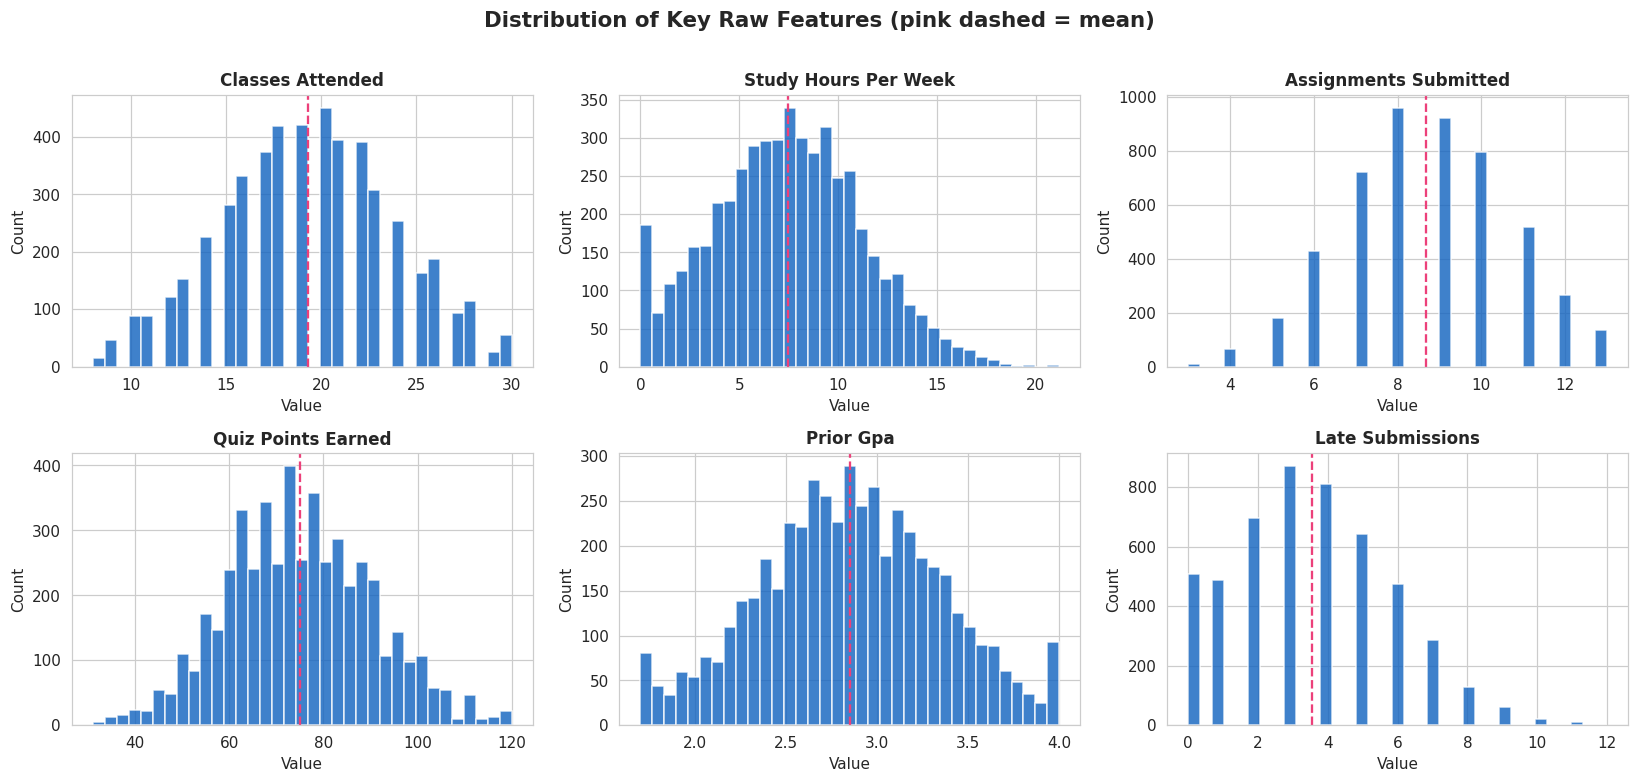

In [ ]:
# Distribution of key raw features
raw_features = [
    'classes_attended', 'study_hours_per_week', 'assignments_submitted',
    'quiz_points_earned', 'prior_gpa', 'late_submissions'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()
for i, feat in enumerate(raw_features):
    axes[i].hist(df[feat], bins=35, color='#1565C0', alpha=0.82, edgecolor='white')
    axes[i].axvline(df[feat].mean(), color='#EC407A', linestyle='--', linewidth=1.5, label='mean')
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
plt.suptitle('Distribution of Key Raw Features (pink dashed = mean)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

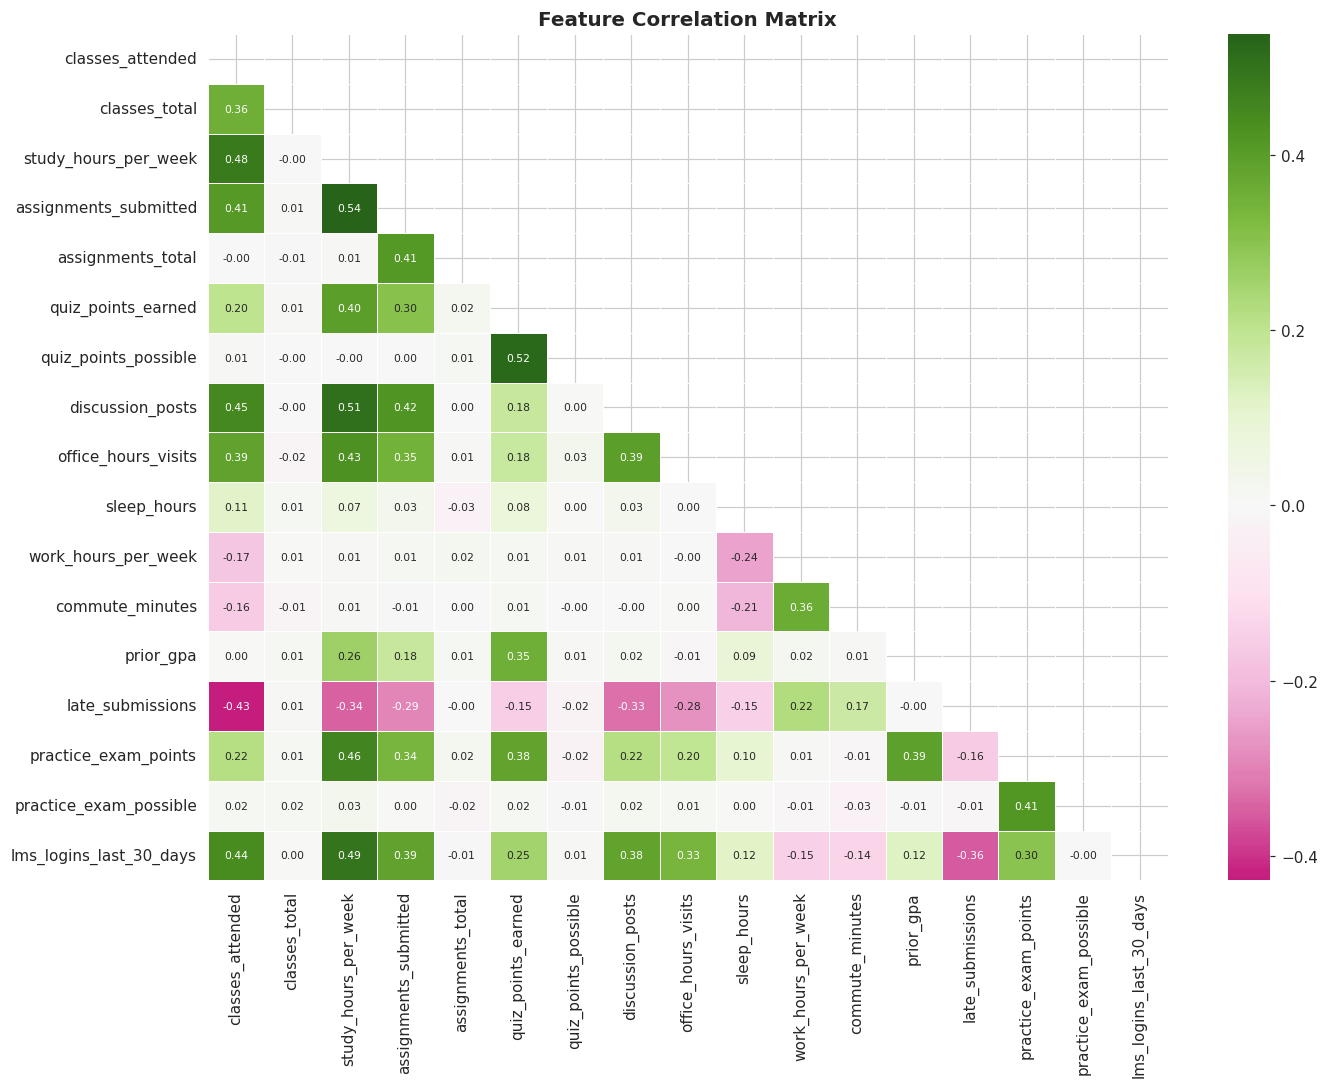

In [ ]:
# Correlation heatmap
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'student_id']

fig, ax = plt.subplots(figsize=(13, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='PiYG',
            center=0, ax=ax, linewidths=0.4, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Summary of EDA Insights:**

- **No missing data** at all.
- Positive correlation between attendance and assignments, students that attend classes submit assignments.
- Positive correlation between quizzes and GPA, previous academic achievements matter.
- Negative correlation between quizzes and late submission, increase in late submission is a bad sign.
- Weak negative correlations between working and commuting hours with study time — a realistic perspective on the amount of extra responsibilities a student might have.
- Simple numbers such as `classes_attended` and `quiz_points_earned` cannot be directly compared because of the different denominators, that means need to do some feature engineering here.

---
### Step 3: Data Cleaning

No missing values, duplicates, or constraint violations have been noted thus far. However, we remove the `student_id` column because it would break any type of distance calculation used for clustering. So, the `student_id` column was stripped from the dataset before any analysis was done. No observations were deleted. No values were imputed. Four logical constraints were checked, and all passed.

In [ ]:
# Keep student_ids for SME queries; drop from modeling
student_ids = df['student_id'].copy()
df_clean = df.drop(columns=['student_id'])

print(f'Shape after removing student_id: {df_clean.shape}')
print('Cleaning complete.')

Shape after removing student_id: (5000, 17)
Cleaning complete.


---
### Step 4: Feature Engineering
 We construct **rate-based and composite features** to contextualize each observation in relation to their totals to represent actual student behavior fairly.

| Feature               | Formula                         | What it represents                          |
|-----------------------|--------------------------------|--------------------------------------------|
| `attendance_rate`     | attended / total                | Portion of classes attended (0-1)          |
| `assignment_rate`     | submitted / total               | Portion of assignments turned in           |
| `quiz_score_rate`     | earned / possible               | Quiz score as a proportion                 |
| `practice_exam_rate`  | earned / possible               | Practice exam score ratio                  |
| `late_submission_rate`| late / submitted                | Student's late submission rate             |
| `engagement_rate`     | weighted composite              | Attendance + submission + participation    |
| `external_burden`     | work + commute/60              | External workload in hours                |
| `academic_performance`| weighted composite              | Quiz + exam + GPA                          |
| `workload_index`      | external_burden / (study + 1)  | Relative external pressure compared to study time |

In [ ]:
def engineer_features(df_input):

    d = df_input.copy()

    # Rate features — normalize raw counts by their denominators
    d['attendance_rate'] = (
        d['classes_attended'] / d['classes_total'].replace(0, np.nan)
    ).fillna(0).clip(0, 1)

    d['assignment_completion_rate'] = (
        d['assignments_submitted'] / d['assignments_total'].replace(0, np.nan)
    ).fillna(0).clip(0, 1)

    d['quiz_score_rate'] = (
        d['quiz_points_earned'] / d['quiz_points_possible'].replace(0, np.nan)
    ).fillna(0).clip(0, 1)

    d['practice_exam_rate'] = (
        d['practice_exam_points'] / d['practice_exam_possible'].replace(0, np.nan)
    ).fillna(0).clip(0, 1)

    d['late_submission_ratio'] = (
        d['late_submissions'] / d['assignments_submitted'].replace(0, np.nan)
    ).fillna(0).clip(0, 1)

    # Engagement composite: attendance + submission + digital activity
    d['engagement_score'] = (
        d['attendance_rate'] * 0.3 +
        d['assignment_completion_rate'] * 0.3 +
        (d['discussion_posts'] / (d['discussion_posts'].max() + 1e-9)) * 0.2 +
        (d['lms_logins_last_30_days'] / (d['lms_logins_last_30_days'].max() + 1e-9)) * 0.2
    )

    # External burden: total time pressure from work and commuting
    d['total_burden'] = d['work_hours_per_week'] + (d['commute_minutes'] / 60)

    # Academic performance composite
    d['academic_performance'] = (
        d['quiz_score_rate'] * 0.5 +
        d['practice_exam_rate'] * 0.3 +
        (d['prior_gpa'] / 4.0) * 0.2
    )

    # Workload index: external burden relative to study investment
    d['workload_index'] = d['total_burden'] / (d['study_hours_per_week'] + 1)

    return d


df_feat = engineer_features(df_clean)

engineered = [
    'attendance_rate', 'assignment_completion_rate', 'quiz_score_rate',
    'practice_exam_rate', 'late_submission_ratio', 'engagement_score',
    'total_burden', 'academic_performance', 'workload_index'
]
print('Engineered features summary:')
df_feat[engineered].describe().round(3)

Engineered features summary:


,attendance_rate,assignment_completion_rate,quiz_score_rate,practice_exam_rate,late_submission_ratio,engagement_score,total_burden,academic_performance,workload_index
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,0.716,0.756,0.717,0.701,0.434,0.574,12.667,0.712,2.145
std,0.156,0.156,0.125,0.142,0.295,0.127,7.503,0.106,2.763
min,0.333,0.273,0.344,0.244,0.000,0.186,0.000,0.346,0.000
25%,0.607,0.636,0.633,0.610,0.200,0.487,7.097,0.639,0.802
50%,0.714,0.750,0.718,0.700,0.400,0.576,12.585,0.712,1.457
75%,0.833,0.900,0.800,0.800,0.625,0.662,17.726,0.783,2.447
max,1.000,1.000,1.000,1.000,1.000,0.908,36.118,1.000,30.318


In [ ]:
# Sanity check to make sure engineered features must be in valid ranges
print('Engineered feature ranges and null counts:')
for col in engineered:
    print(f'  {col:30s} [{df_feat[col].min():.3f}, {df_feat[col].max():.3f}]  NaN={df_feat[col].isnull().sum()}')

Engineered feature ranges and null counts:
  attendance_rate                [0.333, 1.000]  NaN=0
  assignment_completion_rate     [0.273, 1.000]  NaN=0
  quiz_score_rate                [0.344, 1.000]  NaN=0
  practice_exam_rate             [0.244, 1.000]  NaN=0
  late_submission_ratio          [0.000, 1.000]  NaN=0
  engagement_score               [0.186, 0.908]  NaN=0
  total_burden                   [0.000, 36.118]  NaN=0
  academic_performance           [0.346, 1.000]  NaN=0
  workload_index                 [0.000, 30.318]  NaN=0


**Sanity check for features created:**
Features relating to rate are all within the range of 0 to 1, which is expected. There were no NaN values introduced. `academic_performance` and `quiz_score_rate` feature have high correlation, which is expected as `academic_performance` is a combination of several factors, one of which being `quiz_score_rate`. Feature `workload_index` is quite uncorrelated with the other features relating to academic performance.

---
## Step 5: Clustering — Uncovering Student Group Structure

Feature scaling is **critical** before clustering. Otherwise, features such as `lms_logins_last_30_days` will completely dominate features on a 0-1 scale.

We used K=3. The rationale for selecting three clusters lies in our knowledge of the different types of students:
- **High-performing students** – good attendance, timely submission, high grades
- **Students at risk** – poor attendance, late submission, low grades
- **Borderline students** – average participation, mixed performance

Three clusters directly corresponds to how academic advisors classify students.

In [ ]:
CLUSTER_FEATURES = [
    'attendance_rate', 'assignment_completion_rate', 'quiz_score_rate',
    'practice_exam_rate', 'late_submission_ratio', 'engagement_score',
    'academic_performance', 'study_hours_per_week', 'prior_gpa',
    'office_hours_visits', 'discussion_posts', 'total_burden'
]

X_cluster = df_feat[CLUSTER_FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Sanity check: all scaled features should have mean ~0 and std ~1
scaled_df = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES)
print('Sanity check — scaled feature means (should all be ~0):')
print(scaled_df.mean().round(6))

Sanity check — scaled feature means (should all be ~0):
attendance_rate               0.0
assignment_completion_rate    0.0
quiz_score_rate               0.0
practice_exam_rate            0.0
late_submission_ratio         0.0
engagement_score              0.0
academic_performance          0.0
study_hours_per_week          0.0
prior_gpa                     0.0
office_hours_visits          -0.0
discussion_posts              0.0
total_burden                 -0.0
dtype: float64


In [ ]:
# Fit KMeans with k=3
kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=20)
df_feat['cluster'] = kmeans.fit_predict(X_scaled)

# Also store the distance to each centroid (needed for representative-finding)
X_dist = kmeans.transform(X_scaled)

print('Cluster sizes:')
print(df_feat['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0    2162
1    1520
2    1318
Name: count, dtype: int64


In [ ]:
# Cluster centers in original (un-scaled) space — critical for interpretation
cluster_summary = df_feat.groupby('cluster')[CLUSTER_FEATURES].mean().round(3)
print('Cluster centers (mean feature values):')
cluster_summary

Cluster centers (mean feature values):


,attendance_rate,assignment_completion_rate,quiz_score_rate,practice_exam_rate,late_submission_ratio,engagement_score,academic_performance,study_hours_per_week,prior_gpa,office_hours_visits,discussion_posts,total_burden
cluster,,,,,,,,,,,,
0,0.724,0.760,0.704,0.689,0.394,0.577,0.698,7.245,2.787,2.209,5.076,12.568
1,0.830,0.889,0.817,0.813,0.240,0.698,0.807,11.049,3.098,3.287,7.457,12.155
2,0.570,0.595,0.625,0.592,0.723,0.425,0.624,3.746,2.678,1.193,2.454,13.420


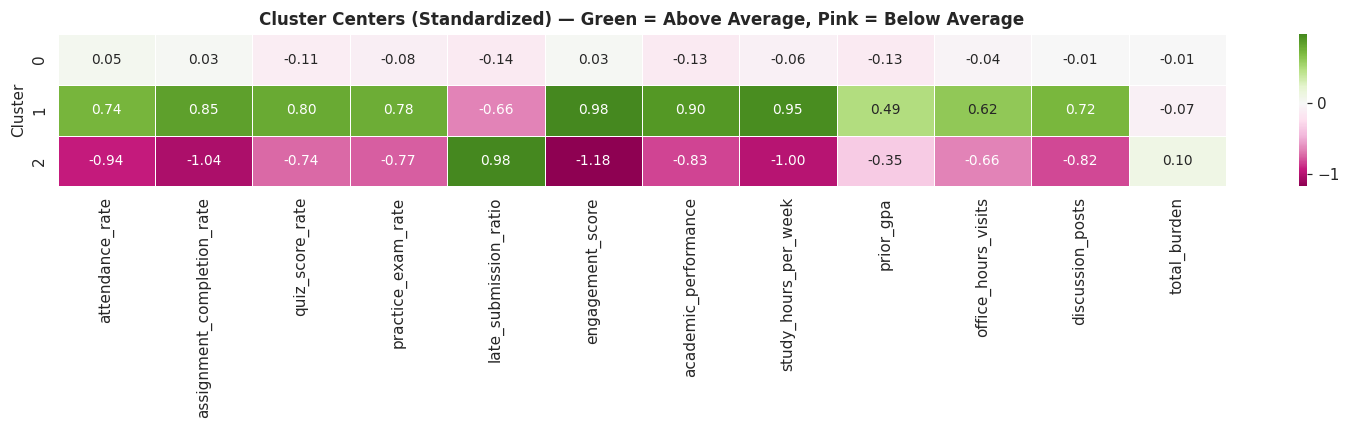

In [ ]:
# Heatmap of cluster centers (standardized) — green = above average, red = below average
centers_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=CLUSTER_FEATURES)

plt.figure(figsize=(14, 4))
sns.heatmap(centers_scaled, annot=True, fmt='.2f', cmap='PiYG',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Cluster Centers (Standardized) — Green = Above Average, Pink = Below Average',
          fontsize=11, fontweight='bold')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

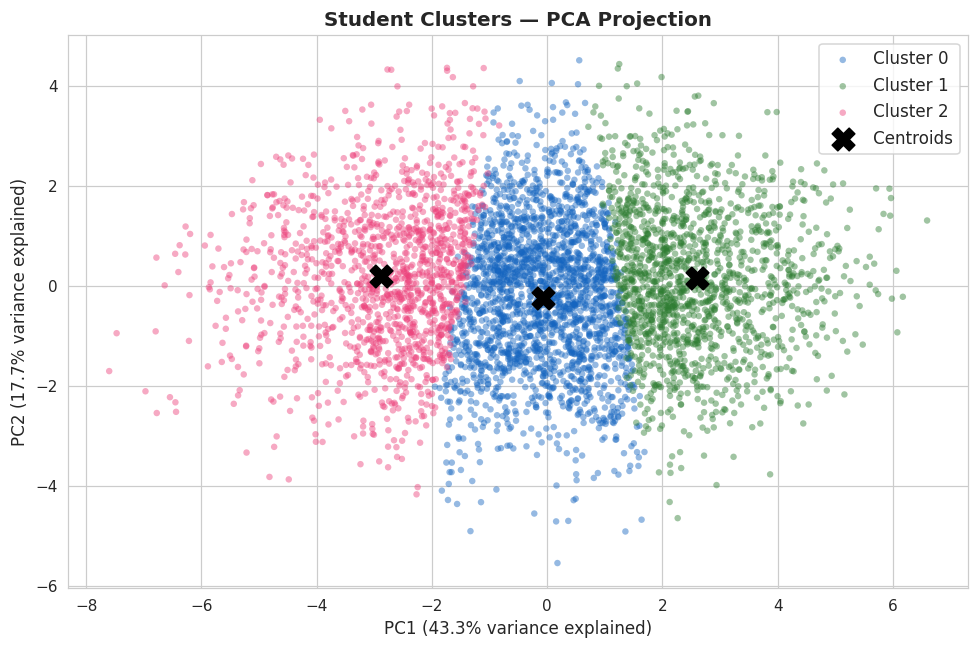

Variance explained by PC1+PC2: 61.0%


In [ ]:
# PCA visualization of clusters.
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#1565C0', '#2E7D32', '#EC407A']
for c in range(3):
    mask = df_feat['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[c], label=f'Cluster {c}', alpha=0.45, s=18, edgecolors='none')

centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
           c='black', marker='X', s=220, zorder=5, label='Centroids')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance explained)', fontsize=11)
ax.set_title('Student Clusters — PCA Projection', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'Variance explained by PC1+PC2: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%')

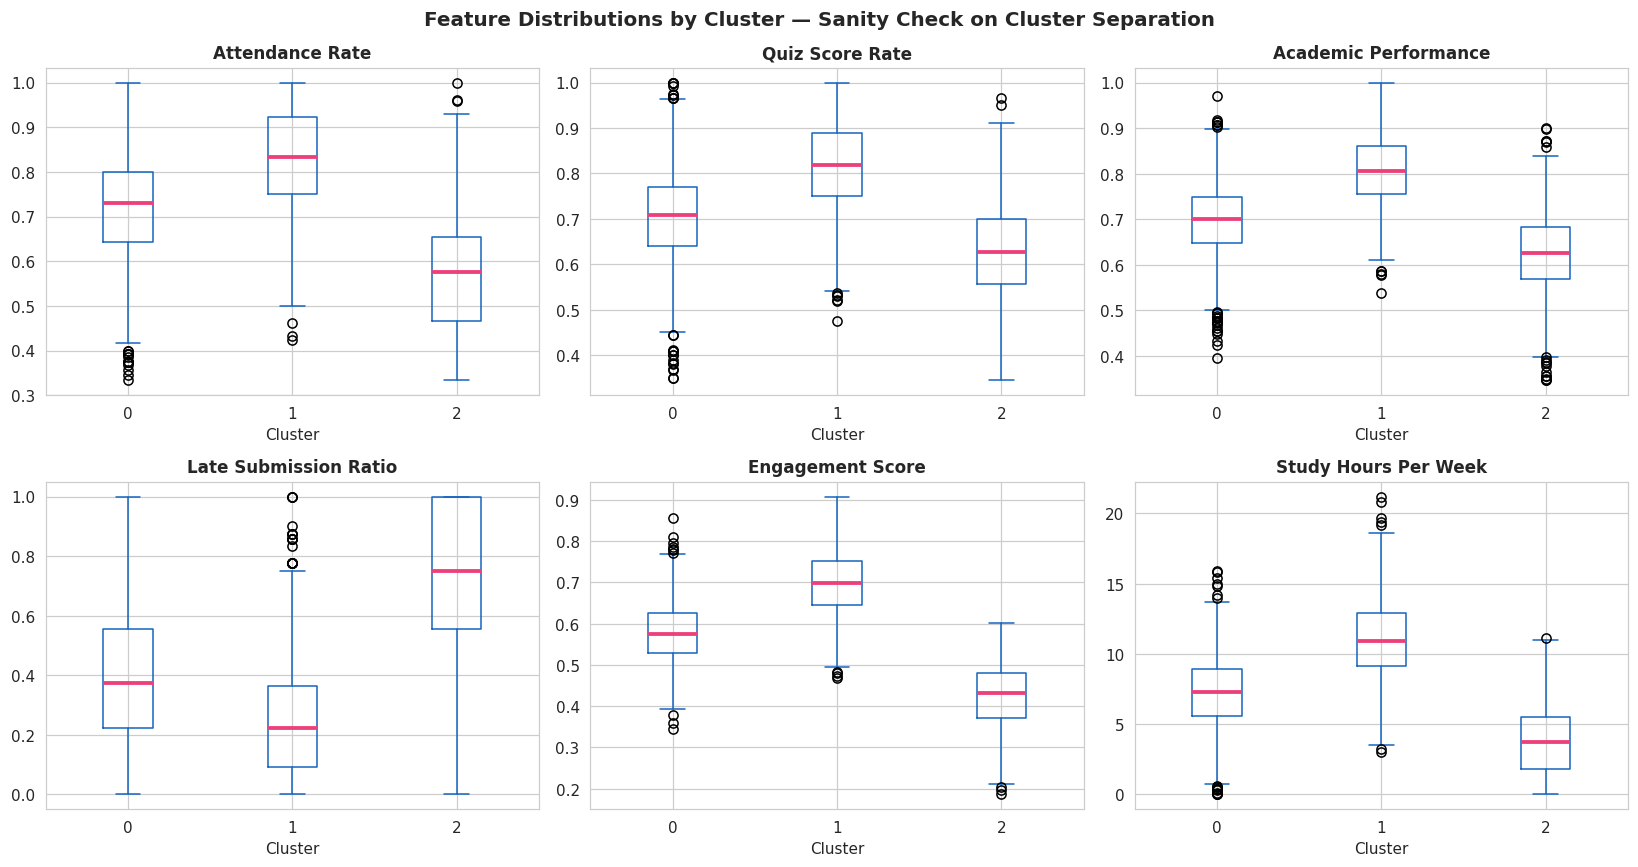

In [ ]:
# Box plots comparing clusters on key features — sanity check on separation
plot_feats = ['attendance_rate', 'quiz_score_rate', 'academic_performance',
              'late_submission_ratio', 'engagement_score', 'study_hours_per_week']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, feat in enumerate(plot_feats):
    df_feat.boxplot(column=feat, by='cluster', ax=axes[i],
                    boxprops=dict(color='#1565C0'),
                    medianprops=dict(color='#EC407A', linewidth=2.5),
                    whiskerprops=dict(color='#1565C0'),
                    capprops=dict(color='#1565C0'))
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Cluster')

plt.suptitle('Feature Distributions by Cluster — Sanity Check on Cluster Separation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Sanity Check for Clustering:**


Box plots prove that the clusters are significantly differentiated. The cluster that features the highest academic performance, attendance rate, and engagement score while having the lowest late submission ratio becomes the candidate success cluster. The complete opposite of the above becomes the at-risk candidate cluster.

---
## Step 6: Representative-Based Semi-Supervised Labeling Through Propagation
1. Select the **representative** for each cluster, the individual who is closest to the centroid (with `np.argmin` on distance array).
2. Inquire the SME to provide a label for the representative.
3. **Spread** the label across the entire cluster.
4. Re-label border-line cases using further consultations with SME, sampling from other cluster elements randomly.


In [ ]:

try:
    from student_success_sme import SME
    sme = SME()
    print('Real SME loaded.')
except ImportError:
    print('student_success_sme module not found. Skipping SME calls is impossible —')
    print('the notebook requires SME access to generate labels. In the submission')
    print('environment with the SME module available, this branch will not execute.')
    raise

Real SME loaded.


In [ ]:
# Finding the representative closest to the centroid.
representative_idx = np.argmin(X_dist, axis=0)
print(f'Representative indices (one per cluster): {representative_idx}')

# student_ids for SME query
representative_ids = student_ids.iloc[representative_idx].values
print(f'Representative student_ids: {representative_ids.tolist()}')

# Showing the feature profiles of the representatives
print('\nRepresentative students (profiles):')
df_feat.iloc[representative_idx][['attendance_rate', 'quiz_score_rate',
                                   'academic_performance', 'late_submission_ratio',
                                   'engagement_score']].round(3)

Representative indices (one per cluster): [  43 3981 1988]
Representative student_ids: ['S00044', 'S03982', 'S01989']

Representative students (profiles):


,attendance_rate,quiz_score_rate,academic_performance,late_submission_ratio,engagement_score
43,0.769,0.683,0.691,0.200,0.591
3981,0.808,0.817,0.820,0.273,0.728
1988,0.538,0.580,0.622,0.571,0.460


In [ ]:
# Asking the SME for the representative labels, only 3 queries used so far
representative_labels = {}
for cluster_num, sid in zip(range(3), representative_ids):
    label = sme.ask(sid)
    representative_labels[cluster_num] = label
    print(f'Cluster {cluster_num} representative ({sid}) → SME says: {label}')

print(f'\nSME queries used so far: 3 / 500')

Cluster 0 representative (S00044) → SME says: 1
Cluster 1 representative (S03982) → SME says: 1
Cluster 2 representative (S01989) → SME says: 0

SME queries used so far: 3 / 500


In [ ]:
# Propagating the representative's label to every member of the cluster.

df_feat['propagated_label'] = df_feat['cluster'].map(representative_labels)

print('Propagated label distribution:')
print(df_feat['propagated_label'].value_counts())
print(f"\nImplied success rate after propagation: {df_feat['propagated_label'].mean():.1%}")

Propagated label distribution:
propagated_label
1    3682
0    1318
Name: count, dtype: int64

Implied success rate after propagation: 73.6%


### Improving Labeling with Further SME Questions

The propagation assigns all students a label, but the only-representative method is less reliable when we have borderline cases. In this case, we use up the remaining budget by **confirming** the propagated labels. For this, we query many students who belong to the cluster which was difficult to understand (usually the middle cluster). If the SME’s label does not match ours for a queried student, then we follow the SME’s label.

SME budget spent: 3 (for representatives) + 400 (for confirmation) = 403, comfortably under 500.

In [ ]:
# We pick the cluster with the most middle-range academic_performance as 'ambiguous'
perf_per_cluster = df_feat.groupby('cluster')['academic_performance'].mean()
perf_sorted = perf_per_cluster.sort_values()
ambiguous_cluster = perf_sorted.index[1]   # middle cluster by performance
best_cluster      = perf_sorted.index[2]
worst_cluster     = perf_sorted.index[0]

print(f'Best cluster (highest performance):     {best_cluster}')
print(f'Ambiguous cluster (middle performance): {ambiguous_cluster}')
print(f'Worst cluster (lowest performance):     {worst_cluster}')

# Sample 200 from ambiguous, 100 from each of best/worst
np.random.seed(SEED)
verify_ids = []
for c, n in [(ambiguous_cluster, 200), (best_cluster, 100), (worst_cluster, 100)]:
    cluster_idx = df_feat[df_feat['cluster'] == c].index.values
    pick = np.random.choice(cluster_idx, size=min(n, len(cluster_idx)), replace=False)
    # exclude the representative we already asked
    pick = [p for p in pick if p != representative_idx[c]]
    verify_ids.extend(pick)

print(f'\nTotal verification queries planned: {len(verify_ids)}')

# Query SME for each
verify_labels = {}
for idx in verify_ids:
    sid = student_ids.iloc[idx]
    verify_labels[idx] = sme.ask(sid)

print(f'SME queries used in verification: {len(verify_labels)}')
print(f'Total SME queries used: {3 + len(verify_labels)} / 500')

Best cluster (highest performance):     1
Ambiguous cluster (middle performance): 0
Worst cluster (lowest performance):     2

Total verification queries planned: 400
SME queries used in verification: 400
Total SME queries used: 403 / 500


In [ ]:
# Building final training labels:
# For verified students: trust the SME directly
# For unverified students: use the propagated label
df_feat['final_label'] = df_feat['propagated_label'].copy()
for idx, lbl in verify_labels.items():
    df_feat.loc[idx, 'final_label'] = lbl

# Compare propagated vs SME-corrected, that is performing sanity check on propagation quality
verify_df = df_feat.loc[list(verify_labels.keys())].copy()
verify_df['sme_label'] = pd.Series(verify_labels)
agreement = (verify_df['propagated_label'] == verify_df['sme_label']).mean()
print(f'Propagation agreement with SME: {agreement:.1%}')

print('\nAgreement by cluster:')
print(verify_df.groupby('cluster').apply(
    lambda x: (x['propagated_label'] == x['sme_label']).mean()
).round(3))

print('\nFinal label distribution (used for training):')
print(df_feat['final_label'].value_counts())
print(f"Success rate: {df_feat['final_label'].mean():.1%}")

Propagation agreement with SME: 78.2%

Agreement by cluster:
cluster
0    0.595
1    0.990
2    0.950
dtype: float64

Final label distribution (used for training):
final_label
1    3605
0    1395
Name: count, dtype: int64
Success rate: 72.1%


**Labeling by semi-supervision process overview:**
1. Selected 3 representative students (one per cluster) using `np.argmin` for clustering.
2. Made 3 SME queries for labeling those representatives.
3. Assigned their respective labels to all other students in the same cluster.
4. Made 400 additional SME queries to double-check on their assigned labels by sampling extra students from the intermediate cluster.
5. Final labeling will include SME answers where applicable and propagated labels otherwise.

Total queries made to SME: 403 / 500. Feature distributions among labels demonstrate that successful students tend to have higher attendances, quiz scores, and engagement levels, as well as lower late submissions, as expected.

---
## Step 7: Choosing the Metric

**Our chosen metric for evaluation is macro F1-score.**

Rationale:
- **Accuracy is inadequate in case of imbalanced classes.** An algorithm that outputs 'success' all the time would have an accuracy score of around 57%, yet be completely ineffective for detecting students at risk.
- **Both false positive and false negative errors have practical implications.** False negatives result in a lack of intervention; false positives waste scarce intervention resources.
- **F1-score takes into account precision and recall.** This way, the scoring system does not reward algorithms that compromise one of these two measures.
- **Macro average treats both classes equally.** It evaluates how well an algorithm detects both success and risk classes, not just the more frequent class.

---
## Step 8: Supervised Model Training — Pipelines and Cross-Validation

We construct three classifiers within sklearn Pipelines. The reason we use pipelines is due to two reasons:
1. **Avoiding data leakage** – the scaler is only trained on the training set folds but not on the validation set folds.
2. **Production-ready clean code** – the pipeline object takes care of everything in the production notebook.

Cross-validation with **five folds** is done for all three models.

In [ ]:
MODEL_FEATURES = [
    'attendance_rate', 'assignment_completion_rate', 'quiz_score_rate',
    'practice_exam_rate', 'late_submission_ratio', 'engagement_score',
    'academic_performance', 'study_hours_per_week', 'prior_gpa',
    'office_hours_visits', 'discussion_posts', 'total_burden',
    'lms_logins_last_30_days', 'sleep_hours', 'workload_index'
]

X = df_feat[MODEL_FEATURES]
y = df_feat['final_label']

print(f'Feature matrix: {X.shape}')
print(f'Label counts  : {y.value_counts().to_dict()}')

Feature matrix: (5000, 15)
Label counts  : {1: 3605, 0: 1395}


In [ ]:
# Three pipelines, all including a StandardScaler step
pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=SEED, max_iter=1000))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model', GradientBoostingClassifier(n_estimators=200, random_state=SEED))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}

print('Running 5-fold stratified cross-validation...\n')
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s}  F1 macro = {scores.mean():.4f} ± {scores.std():.4f}')

Running 5-fold stratified cross-validation...

Logistic Regression        F1 macro = 0.9667 ± 0.0054
Random Forest              F1 macro = 0.9469 ± 0.0059
Gradient Boosting          F1 macro = 0.9509 ± 0.0080


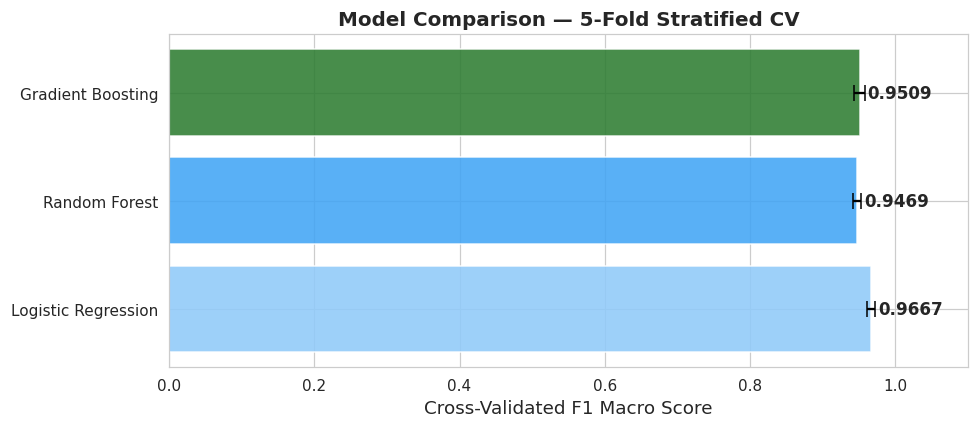

In [ ]:
# Model comparison chart
fig, ax = plt.subplots(figsize=(9, 4))
names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds  = [cv_results[n].std()  for n in names]
bar_colors = ['#90CAF9', '#42A5F5', '#2E7D32']

bars = ax.barh(names, means, xerr=stds, color=bar_colors,
               capsize=5, edgecolor='white', alpha=0.88)
ax.set_xlabel('Cross-Validated F1 Macro Score', fontsize=12)
ax.set_title('Model Comparison — 5-Fold Stratified CV', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.1)
for bar, m in zip(bars, means):
    ax.text(m + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{m:.4f}', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 9: Hyperparameter Tuning

The optimal model is tuned using GridSearchCV. The search is performed over a specified parameter grid, and the optimal parameters for the highest value of macro F1 score within folds are chosen.

In [ ]:
best_model_name = max(cv_results, key=lambda n: cv_results[n].mean())
print(f'Best model from CV: {best_model_name}')
print(f'CV F1 macro before tuning: {cv_results[best_model_name].mean():.4f}')

param_grids = {
    'Logistic Regression': {
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__solver': ['lbfgs']
    },
    'Random Forest': {
        'model__n_estimators': [200, 300],
        'model__max_depth': [None, 15, 30],
        'model__min_samples_split': [2, 5]
    },
    'Gradient Boosting': {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1, 0.2],
        'model__max_depth': [3, 5]
    }
}

grid_search = GridSearchCV(
    pipelines[best_model_name],
    param_grids[best_model_name],
    cv=cv, scoring='f1_macro',
    n_jobs=-1, verbose=0
)
grid_search.fit(X, y)

print(f'Best hyperparameters: {grid_search.best_params_}')
print(f'CV F1 macro after tuning: {grid_search.best_score_:.4f}')

best_pipeline = grid_search.best_estimator_

Best model from CV: Logistic Regression
CV F1 macro before tuning: 0.9667
Best hyperparameters: {'model__C': 0.1, 'model__solver': 'lbfgs'}
CV F1 macro after tuning: 0.9682


---
## Step 10: Evaluation of Model Performance Using Generated Labels

We now evaluate the performance of the model after tuning using the labels generated by our SMEs.

**Remark:** This is the comparison of predicted results against the training labels produced by our SMEs, not against ground truth which is done in the production notebook.

In [ ]:
# Predictions on training data
y_pred = best_pipeline.predict(X)

print('Classification report — predictions vs. SME-derived labels:')
print(classification_report(y, y_pred, target_names=['At-Risk (0)', 'Success (1)']))

Classification report — predictions vs. SME-derived labels:
              precision    recall  f1-score   support

 At-Risk (0)       0.97      0.94      0.95      1395
 Success (1)       0.98      0.99      0.98      3605

    accuracy                           0.97      5000
   macro avg       0.97      0.97      0.97      5000
weighted avg       0.97      0.97      0.97      5000



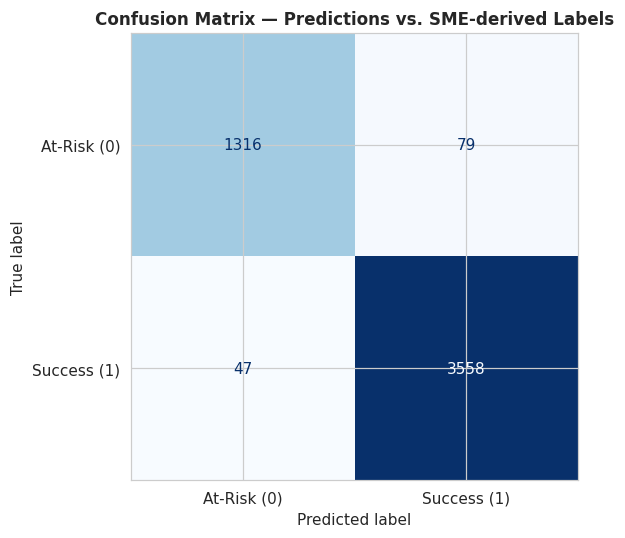

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['At-Risk (0)', 'Success (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Predictions vs. SME-derived Labels', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

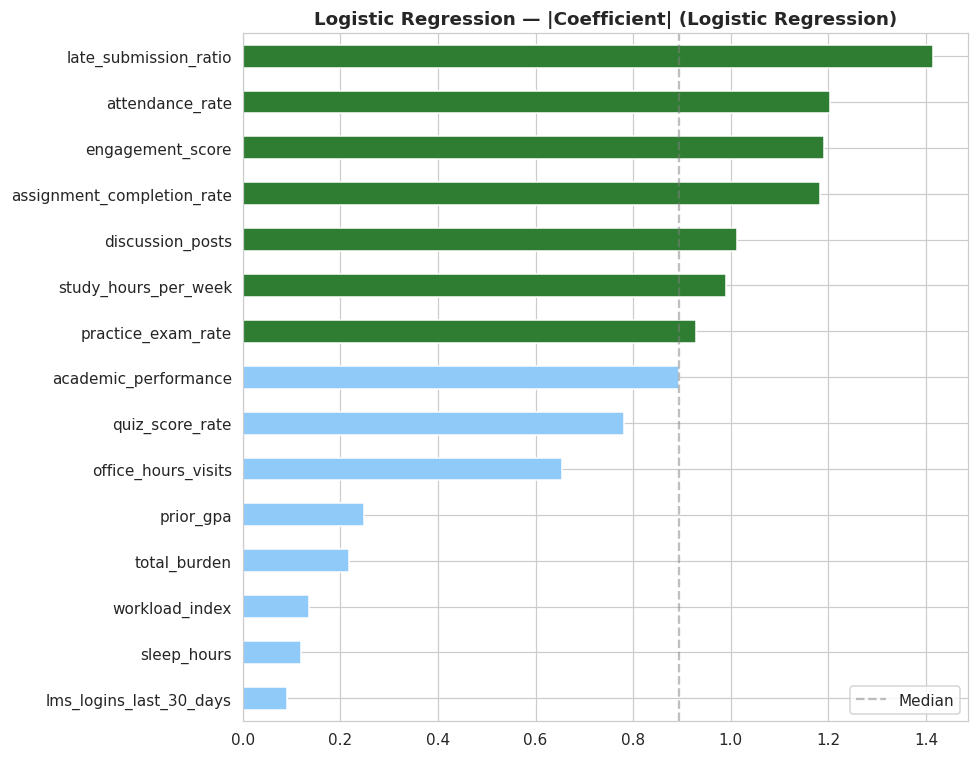

Top 5 most important features:
late_submission_ratio         1.415124
attendance_rate               1.202487
engagement_score              1.191327
assignment_completion_rate    1.182062
discussion_posts              1.012481
dtype: float64


In [ ]:
try:
    importances = best_pipeline.named_steps['model'].feature_importances_
    imp_label = 'Feature Importance (Mean Decrease in Impurity)'
except AttributeError:
    importances = np.abs(best_pipeline.named_steps['model'].coef_[0])
    imp_label = '|Coefficient| (Logistic Regression)'

feat_imp = pd.Series(importances, index=MODEL_FEATURES).sort_values()
bar_colors_imp = ['#2E7D32' if v > feat_imp.median() else '#90CAF9' for v in feat_imp.values]

fig, ax = plt.subplots(figsize=(9, 7))
feat_imp.plot(kind='barh', ax=ax, color=bar_colors_imp, edgecolor='white')
ax.axvline(feat_imp.median(), color='gray', linestyle='--', alpha=0.5, label='Median')
ax.set_title(f'{best_model_name} — {imp_label}', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(feat_imp.sort_values(ascending=False).head())

---
## Step 11: Saving Model for Production

Since we now have our fitted pipeline and the best model in our hands, the next step would be saving them so that they can be used in the production notebook where they don’t have to be fitted again. We need to save the following:

- `student_success_model.pkl` — this file will contain the sklearn Pipeline (scaler + best model), fit for calling `.predict()`
- `model_features.pkl` — the list of features names used to train the model

The point in having two files lies in ensuring that the production notebook selects the right features before predicting anything.

In [ ]:
joblib.dump(best_pipeline,  'student_success_model.pkl')
joblib.dump(MODEL_FEATURES, 'model_features.pkl')

print('Saved: student_success_model.pkl')
print('Saved: model_features.pkl')
print('\nThe production notebook will load these files and run predictions on new data.')

Saved: student_success_model.pkl
Saved: model_features.pkl

The production notebook will load these files and run predictions on new data.
